# Klasifikace finančního sentimentu

# Logistická regrese pro klasifikaci textu

Logistická regrese je statistický model, který odhaduje **pravděpodobnost** příslušnosti vzorku k dané třídě pomocí sigmoidu lineárního vztahu.

---

## 1. Principy a definice modelu

Mějme matici příznaků $X$ o rozměrech $m \times n$ a vektor skutečných tříd $y \in \{0, 1\}$.

Chceme modelovat:

$$z = w \cdot X + b$$

Kde:
* $w$ je vektor vah (důležitost jednotlivých slov).
* $b$ je bias (obecný sklon).



Výsledná predikovaná pravděpodobnost $\hat{y}$ se získá transformací skóre $z$ pomocí sigmoid funkce:

$$\hat{y} = \sigma(z) = \frac{1}{1 + e^{-z}}$$

Klasifikační pravidlo (prahování) pro určení finální třídy:
$$\text{Třída} = \begin{cases} 1 & \text{pokud } \hat{y} \ge 0.5 \\ 0 & \text{pokud } \hat{y} < 0.5 \end{cases}$$

---

## 2. Ztrátová funkce s $L_2$ regularizací

K optimalizaci parametrů a současnému zamezení přetrénování (overfittingu) na specifických slovech se používá binární křížová entropie rozšířená o regularizační člen:

$$J(w, b) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right] + \frac{\lambda}{2m} \sum_{j=1}^{n} w_j^2$$

### Mechanismus penalizace

1. **Základní ztráta (Log-Loss):** Trestá model za špatnou předpověď. Pokud model predikuje pravděpodobnost blízkou 0 pro vzorek, který je ve skutečnosti 1, chyba roste logaritmicky k nekonečnu ($-\log(\hat{y}) \to \infty$).
2. **Regularizační člen ($\frac{\lambda}{2m} \sum w_j^2$):** Trestá model za příliš vysoké hodnoty vah $w$. Nutí váhy držet se blízko nuly, což vyhlazuje rozhodovací hranici a zajišťuje, že model nevisí na několika málo slovech.

---

## 3. Celková účelová funkce (Optimalizace)

Cílem trénování je iterativně nalézt takové parametry $w$ a $b$, které minimalizují celkovou funkci $J(w, b)$. Toho se dosahuje pomocí **gradientního sestupu** (Gradient Descent), kde v každém kroku (epoše) aktualizujeme váhy proti směru parciálních derivací:

$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

Kde $\alpha$ představuje rychlost učení (learning rate).

# Support Vector Machines (SVM) pro klasifikaci textu

Support Vector Machines (Stroj s podpůrnými vektory) je robustní klasifikační algoritmus, který na rozdíl od logistické regrese nehledá pravděpodobnostní rozdělení, ale snaží se v prostoru příznaků nalézt **optimální nadrovinu (rozhodovací hranici)**.

---

## 1. Geometrický princip a definice nadroviny

Mějme matici příznaků $X$  $m \times n$ a vektor skutečných tříd $y$, kde pro SVM definujeme cílové třídy jako $y^{(i)} \in \{-1, 1\}$.

Rozhodovací nadrovina v $n$-rozměrném prostoru je definována lineární rovnicí:

$$w \cdot x + b = 0$$

Kde:
* $w$ je vektor vah (normálový vektor kolmý k nadrovině), který určuje orientaci nadroviny.
* $b$ je bias (skalár), který určuje posun nadroviny od počátku souřadnic.



Klasifikační pravidlo (predikce) pro nový vzorek $x$ pak závisí pouze na znaménku výsledku:

$$\hat{y} = \text{sign}(w \cdot x + b)$$

---

## 2. Princip maximálního okraje (Margin)

Kolem rozhodovací nadroviny definujeme dvě rovnoběžné hraniční nadroviny, které procházejí nejbližšími datovými body obou tříd. Tyto nejbližší body se nazývají **podpůrné vektory (support vectors)**.

* Pro pozitivní třídu ($y = 1$): $w \cdot x + b = 1$
* Pro negativní třídu ($y = -1$): $w \cdot x + b = -1$

Vzdálenost mezi těmito dvěma hraničními nadrovinami je geometricky vyjádřena jako:

$$\text{Margin} = \frac{2}{\|w\|}$$

Cílem SVM je tuto šířku okraje **maximalizovat**.

---

## 3. Ztrátová funkce: Hinge Loss (Závěsová ztráta)

V reálném světě (zejména u textových dat) nejsou třídy lineárně dokonale separovatelné. K měření této chyby slouží ztrátová funkce **Hinge Loss**.

Hinge Loss je definována jako:

$$L(x, y) = \max(0, 1 - y \cdot (w \cdot x + b))$$



### Mechanismus penalizace

Chování funkce závisí na hodnotě výrazu $y \cdot (w \cdot x + b)$, což je geometrická míra správnosti a jistoty klasifikace:

1. **Správná klasifikace s dostatečným okrajem ($y \cdot (w \cdot x + b) \ge 1$):**
   * Bod leží na správné straně a je dostatečně daleko od rozhodovací linie (mimo okraj).
   * Výraz $1 - y(w \cdot x + b)$ je záporný nebo nulový.
   * $\max(0, \text{záporné číslo}) = 0 \to$ **Ztráta je nulová.**

2. **Správná klasifikace uvnitř okraje ($0 \le y \cdot (w \cdot x + b) < 1$):**
   * Bod je sice klasifikován správně, ale nachází se příliš blízko rozhodovací linie (uvnitř ochranného pásma).
   * Výraz $1 - y(w \cdot x + b)$ je kladný, model dostává **malou penalizaci**, protože porušil ideální šířku okraje.

3. **Chybná klasifikace ($y \cdot (w \cdot x + b) < 0$):**
   * Bod leží na špatné straně rozhodovací linie.
   * Hodnota $y \cdot (w \cdot x + b)$ je záporná, což po odečtení od jedničky generuje vysoké kladné číslo.
   * Model dostává **vysokou penalizaci**, která roste lineárně s tím, jak hluboko v nesprávném území se bod nachází.

---

## 4. Celková účelová funkce (Optimalizace)

Celková funkce, kterou se SVM snaží minimalizovat v průběhu učení.

$$J(w, b) = \frac{1}{2} \|w\|^2 + C \cdot \frac{1}{m} \sum_{i=1}^{m} \max\left(0, 1 - y^{(i)} (w \cdot X^{(i)} + b)\right)$$

Kde:
* $\frac{1}{2} \|w\|^2$ je regularizační člen
* $C$ je hyperparametr řídící kompromis (trade-off) mezi šířkou okraje a množstvím chyb.

---

## 5. Konceptuální srovnání: Logistická regrese vs. SVM

| Vlastnost | Logistická regrese | Support Vector Machines (SVM) |
| :--- | :--- | :--- |
| **Výstup modelu** | Pravděpodobnost $p \in (0, 1)$ příslušnosti ke třídě. | Geometrická pozice vůči nadrovině (rozhodnutí 1 nebo -1). |
| **Ztrátová funkce** | Log-Loss (Binární křížová entropie). | Hinge Loss (Závěsová ztráta). |
| **Citlivost na data** | Bere v úvahu distribuci všech bodů v datasetu. | Záleží pouze na bodech nejbližších k hranici (podpůrné vektory). |
| **Chování chyb** | Penalizuje chybné predikce exponenciálně (logaritmicky). | Penalizuje chybné predikce striktně lineárně od hranice okraje. |

In [ ]:
from data_prep import tokenize, vocabulary, tfidf_sparse, plot_sentiment_distribution, plot_cloud, bar_top_words, plot_confusion_matrix
from logistic_regression import train_lr, predict_lr, compute_loss, predict_new_sentence
from svm import train_svm, predict_svm
import pandas as pd
import numpy as np

data = pd.read_csv("data.csv")
print(data.head())

                                            Sentence Sentiment
0  The GeoSolutions technology will leverage Bene...  positive
1  $ESI on lows, down $1.50 to $2.50 BK a real po...  negative
2  For the last quarter of 2010 , Componenta 's n...  positive
3  According to the Finnish-Russian Chamber of Co...   neutral
4  The Swedish buyout firm has sold its remaining...   neutral


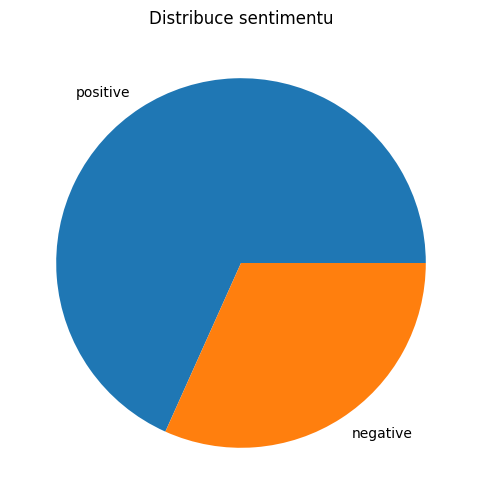

                                            Sentence Sentiment  Label
0       Diluted EPS rose to EUR3 .68 from EUR0 .50 .  positive      1
1  Profit before taxes was EUR 5.4 mn , up from E...  positive      1
2  $FB SHIFTING ON THE 15 MINUTE HERE - SUSPECT T...  positive      1
3  Aberdeen AM posts H1 outflows, says conditions...  negative      0
4  Stockmann and Swedish sector company AB Lindex...  positive      1


In [32]:
data = data[data["Sentiment"] != "neutral"]
data = data.sample(frac=1).reset_index(drop=True)
data['Label'] = data['Sentiment'].apply(lambda x: 1 if x == 'positive' else 0)
plot_sentiment_distribution(data)
print(data.head())

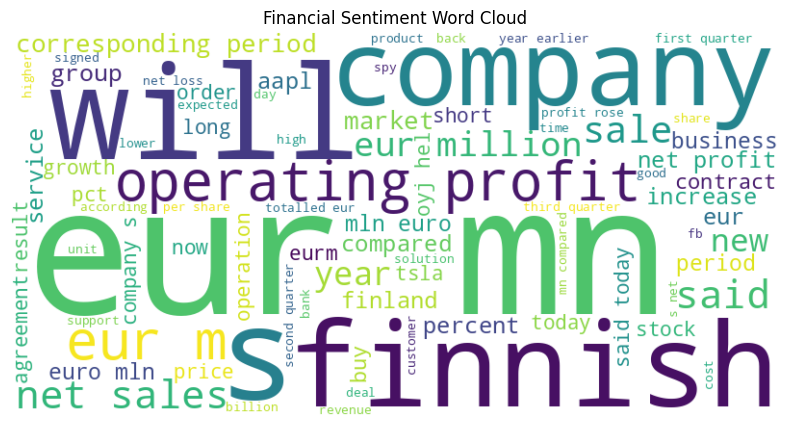

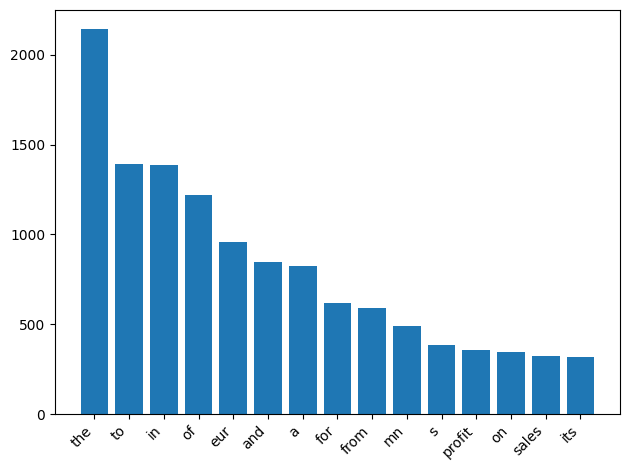

In [33]:
data["Cleaned_tokens"] = data["Sentence"].apply(tokenize)
corpus = data["Cleaned_tokens"].tolist()

plot_cloud(corpus)
bar_top_words(15, corpus)
#Potreba ocistit o stop words

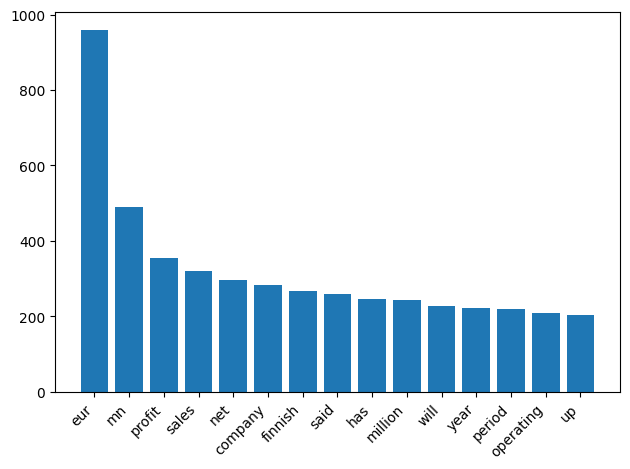

In [34]:
stop_words = ["the", "is", "at", "which", "on", "and", "a", "to", "in", "of", "for", "with", "as", "by", "that", "this", "it", "from", "are", "was", "be", "or", "an", "not", "all", "but", "if", "they", "their", "we", "he", "she", "my", "your", "his", "her", "its", "our", "us", "them", "what", "who", "whom", "which", "whose", "when", "where", "why", "how", "s"]

corpus = [[token for token in doc if token not in stop_words] for doc in corpus]
bar_top_words(15, corpus)

In [35]:
split_idx = int(len(corpus) * 0.8)

X_train = corpus[:split_idx] 
X_test = corpus[split_idx:]
y_train = data["Label"][:split_idx].to_numpy()
y_test = data["Label"][split_idx:].to_numpy()

train_vocab = vocabulary(X_train)

train_tfidf, idf = tfidf_sparse(X_train, train_vocab)
test_tfidf, _ = tfidf_sparse(X_test, train_vocab, idf)

In [36]:
learning_rate = 0.1
epochs = 30_000
lambda_reg = 0.1

weight_0 = len(y_train) / (2 * np.sum(y_train == 0))
weight_1 = len(y_train) / (2 * np.sum(y_train == 1))


weights, bias = train_lr(train_tfidf, np.array(y_train), learning_rate, epochs, lambda_reg, weight_0, weight_1)

Epoch 0, Loss: 0.6931
Epoch 3000, Loss: 0.4952
Epoch 6000, Loss: 0.4002
Epoch 9000, Loss: 0.3416
Epoch 12000, Loss: 0.3012
Epoch 15000, Loss: 0.2713
Epoch 18000, Loss: 0.2481
Epoch 21000, Loss: 0.2296
Epoch 24000, Loss: 0.2143
Epoch 27000, Loss: 0.2015


In [37]:
y_probs = predict_lr(test_tfidf, weights, bias)
test_loss = compute_loss(y_test, y_probs)

y_classes = (y_probs >= 0.5).astype(int)
accuracy = np.mean(y_classes == y_test)

print(f"Test Loss (LogLoss): {test_loss:.4f}")
print(f"Test Accuracy: {accuracy:.2%}")

Test Loss (LogLoss): 0.4074
Test Accuracy: 83.98%


In [38]:
print(predict_new_sentence("The unexpected resignation of the CEO caused a sharp drop in share prices.", train_vocab,weights, bias, idf))

0.3642414640553661


In [39]:
sorted_indices = np.argsort(weights)
top_positive_indices = sorted_indices[-10:]
top_negative_indices = sorted_indices[:10]
print("Top 10 Positive Words: ")
for idx in top_positive_indices[::-1]:
    print(f"  {train_vocab[idx]}: {weights[idx]:.4f}")

print("Top 10 Negative Words: ")
for idx in top_negative_indices:
    print(f"  {train_vocab[idx]}: {weights[idx]:.4f}")

Top 10 Positive Words: 
  up: 5.0156
  rose: 4.9045
  increase: 3.4647
  long: 3.2147
  increased: 3.0706
  grew: 2.5459
  buy: 2.3562
  new: 2.2633
  improved: 2.1200
  positive: 2.1127
Top 10 Negative Words: 
  down: -7.0176
  decreased: -6.1074
  fell: -4.3915
  lower: -4.0445
  fall: -3.1709
  short: -3.0499
  declined: -2.8388
  weak: -2.3939
  cut: -2.3468
  drop: -2.1438


Precision: 0.8611
Recall: 0.9142
F1 Score: 0.8869


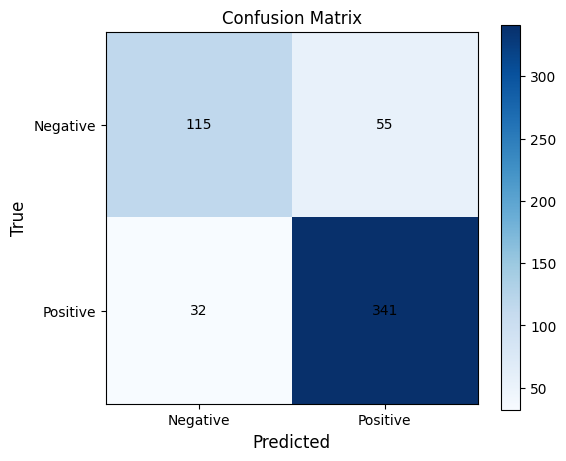

In [40]:
plot_confusion_matrix(y_test, y_classes)

In [41]:
learning_rate = 0.01
epochs = 100_000
lambda_reg = 0.00001


w_svm, b_svm = train_svm(train_tfidf, np.array(y_train), learning_rate, epochs, lambda_reg, weight_0, weight_1,logging=True)

y_svm = predict_svm(test_tfidf, w_svm, b_svm)
print(f"SVM Test Accuracy: {np.mean(y_svm == y_test):.2%}")
plot_confusion_matrix(y_test, y_svm)

Epoch 0, Loss: 1.0000000000044549
Epoch 10000, Loss: 0.6076172097824518
Epoch 20000, Loss: 0.40662092169597247


KeyboardInterrupt: 

In [ ]:
sorted_indices = np.argsort(w_svm)
top_positive_indices = sorted_indices[-10:]
top_negative_indices = sorted_indices[:10]
print("Top 10 Positive Words: ")
for idx in top_positive_indices[::-1]:
    print(f"  {train_vocab[idx]}: {w_svm[idx]:.4f}")

print("Top 10 Negative Words: ")
for idx in top_negative_indices:
    print(f"  {train_vocab[idx]}: {w_svm[idx]:.4f}")

Top 10 Positive Words: 
  up: 3.0802
  rose: 2.6655
  increase: 2.2650
  increased: 2.1100
  grew: 1.7981
  long: 1.3709
  higher: 1.2822
  improved: 1.2363
  buy: 1.2121
  agreement: 1.1458
Top 10 Negative Words: 
  decreased: -4.0012
  down: -3.7297
  fell: -3.2951
  lower: -2.4440
  loss: -2.2317
  declined: -2.1157
  fall: -2.0026
  dropped: -1.8554
  slipped: -1.5763
  short: -1.5199


LA Test Accuracy: 71.45%
Precision: 0.9091
Recall: 0.6469
F1 Score: 0.7559


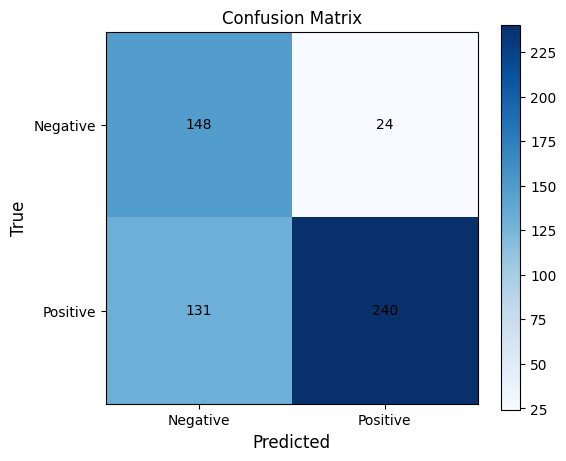

In [ ]:
train_tfidf = train_tfidf.tocsr()
test_tfidf = test_tfidf.tocsr()

avg_pos = np.asarray(train_tfidf[y_train == 1].mean(axis=0)).flatten()
avg_neg = np.asarray(train_tfidf[y_train == 0].mean(axis=0)).flatten()

scores_pos = test_tfidf.dot(avg_pos)
scores_neg = test_tfidf.dot(avg_neg)

y_pred_la = np.where(scores_pos > scores_neg, 1, 0)
accuracy_la = np.mean(y_pred_la == y_test)
print(f"LA Test Accuracy: {accuracy_la:.2%}")
plot_confusion_matrix(y_test, y_pred_la)